<a href="https://colab.research.google.com/github/Priyanshi-6014/Detecting-Outliers-Technique/blob/main/Detecting_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Outliers detection method**

using Wine Quality Dataset to illustrate different techniques.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

df = pd.read_csv("winequality-red.csv")
print(df.shape)
print(df.head())

data = df.drop("quality", axis=1)

(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

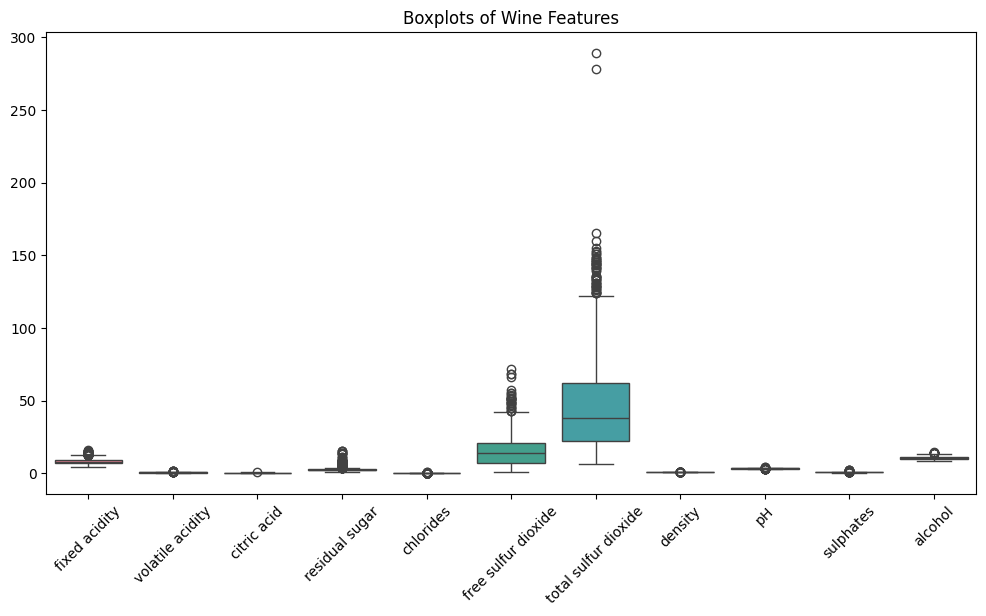

In [2]:
#Visualize
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplots of Wine Features")
plt.show()

we can see black dots represents outliers in our dataset on which we will work now using different techniques like:

## **Z-score method**

 technique that detects outliers based on how far a data point is from the mean, measured in terms of standard deviations. It assumes the data follows a normal distribution

In [3]:
z_scores = np.abs(stats.zscore(data))
outliers_z = np.where(z_scores > 3)

print("Outlier positions (row, col):")
print(list(zip(outliers_z[0][:10], outliers_z[1][:10])))

Outlier positions (row, col):
[(np.int64(13), np.int64(9)), (np.int64(14), np.int64(5)), (np.int64(15), np.int64(5)), (np.int64(15), np.int64(6)), (np.int64(17), np.int64(4)), (np.int64(17), np.int64(9)), (np.int64(19), np.int64(4)), (np.int64(33), np.int64(3)), (np.int64(38), np.int64(1)), (np.int64(42), np.int64(4))]


         ...

## **IQR Method (Interquartile Range)**

It is a robust statistical approach that identifies outliers by examining the spread of the middle 50% of the data. It calculates the Interquartile Range (IQR), which is the difference between the 75th percentile (Q3) and 25th percentile (Q1)

In [4]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
dtype: int64


  ....

## **Isolation Forest**

It is a model-based anomaly detection algorithm that isolates outliers instead of profiling normal data. It builds multiple random decision trees by repeatedly splitting the data.

IsoForest_Outlier
 1    1519
-1      80
Name: count, dtype: int64


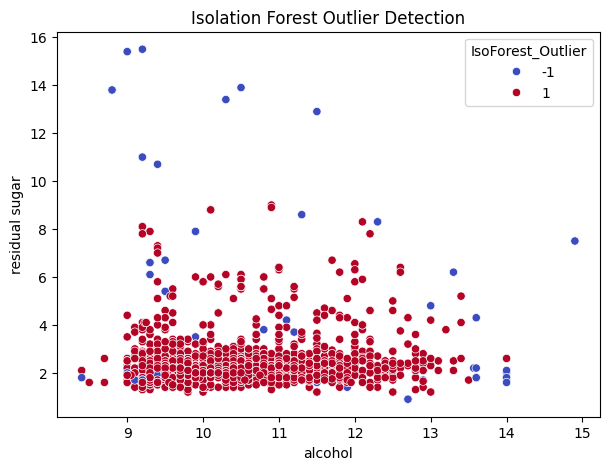

In [5]:
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(data)

df["IsoForest_Outlier"] = y_pred_iso
print(df["IsoForest_Outlier"].value_counts())

plt.figure(figsize=(7, 5))
sns.scatterplot(x="alcohol", y="residual sugar", data=df,
                hue="IsoForest_Outlier", palette="coolwarm")
plt.title("Isolation Forest Outlier Detection")
plt.show()